This can be [run on Google Colab using this link](https://colab.research.google.com/github/NEU-Silicon-Valley/CS7150-CA5/blob/main/CA5.1_LanguageModels.ipynb)
# Language model architectures, from RNNs to Transformers

In this notebook, you will get experience implementing the core logic within a few language model architectures, from RNNs to transformers.

## Preliminaries

Set up here.

In [2]:
# First, we'll implement a simple RNN language model

import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from ipywidgets import FloatSlider, interactive
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
import time
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

SEED = 2025
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda


## Dataset

We will create a **character-based** autoregressive language model, which means, it will predict one character at a time.

To train it, we will need a dataset class that provides character sequences, then we will load some text into it.

We use the TinyStories dataset.  ([Eldan, 2023](https://arxiv.org/abs/2305.07759))

In [3]:

# This class takes a string of text and a sequence length and
# breaks it down to character sequences of the given length.
class CharLMDataset(Dataset):
    def __init__(self, text, seq_length=20):
        self.seq_length = seq_length
        self.vocab = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.vocab)}
        self.itos = {i: ch for i, ch in enumerate(self.vocab)}
        self.encoded_text = [self.stoi[ch] for ch in text]
        # Ensure we have enough tokens for both input and target sequences
        self.encoded_text = self.encoded_text[: len(self.encoded_text) - (len(self.encoded_text) % (seq_length + 1))]

    def __len__(self):
        # Number of complete chunks
        return len(self.encoded_text) // (self.seq_length + 1)

    def __getitem__(self, idx):
        # Get the idx-th chunk
        chunk = self.encoded_text[idx * (self.seq_length + 1) : (idx + 1) * (self.seq_length + 1)]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

# TinyStories (Eldan, 2023)[https://arxiv.org/abs/2305.07759] is a dataset of short, simple stories generated
# by GPT3.5 and GPT4. There about 2B characters in the full dataset, but we'll only use 10M
dataset_size = 10_000_000
batch_size = 32

tinystories = load_dataset("roneneldan/TinyStories")
full_text = "\n".join(tinystories["train"]["text"])[:dataset_size]
print(full_text[:1000])

dataset = CharLMDataset(full_text)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. B

# Recurrent Neural Networks

## Autoregressive Language Modeling

An autoregressive language model predicts the probability distribution of the next token given the previous tokens:

$$
P(x_t | x_{t-1}, x_{t-2}, ..., x_1) = g_\theta(x_{t-1}, x_{t-2}, ..., x_1)
$$

For the complete sequence, the joint probability factorizes as:

$$
P(x_1, ..., x_T) = \prod_{t=1}^T P(x_t | x_{t-1}, ..., x_1)
$$

Now, we need the neural network to plays the role of the abstract function $g_\theta$, which means that it must take a sequence of tokens as input, and produce a categorical distribution over possible next-tokens as output.  But every neural network has a fixed set of neurons.  How can we make one that takes an arbitrarily long sequence of inputs?

The idea of a **Recurrent Neural Network** is to implement the abstract $g_\theta$ as a Recurrent neural network $f_\theta$, that recursively consumes one token at a time.  The idea is to use a hidden state vector $h_t$ that summarizes the sequence history:

$$
g_\theta(x_{1:t}) = \text{softmax}(W_{out}f_\theta(x_t, f_\theta(x_{t-1}, f_\theta(x_{t-2}, ... f_\theta(x_1, h_0)...))) + b_{out})
$$

Each invocation of $f_\theta$ is now simple, consuming a single token and a single hidden state vector.

$
h_t = f_\theta(x_t, h_{t-1})
$


## Token Encoding

Some details: to get tokens into a neural network, we need to encode them as vectors.

Each input token $x_t$ is first mapped to a dense vector through an embedding layer:

$$
e_t = E x_t
$$

where $E \in \mathbb{R}^{d_{emb} \times |V|}$ is the embedding matrix and $|V|$ is the vocabulary size.

The model's hidden state $h_t$ captures the sequence context.

## Token Decoding

Then to get tokens out, we need to produce a distribution of output probabilities for the next token.

To predict the next token, we use a linear classifier that makes a prediction based on the hidden state:

$$
logits = W_{fc} h_t + b_{fc}
$$

$$
P(x_{t+1} | x_t, ..., x_1) = softmax(logits)
$$

where $W_{out} \in \mathbb{R}^{|V| \times d_{hidden}}$ projects the hidden state back to vocabulary-sized logits.

## Elman RNN Architecture

How do we get one hidden state from another?

The vanilla or Elman RNN arcthiecture is given by this rule:

$$
h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})
$$

where:
- $x_t$ is the input embedding at time $t$
- $h_t$ is the hidden state at time $t$
- $W_{ih} \in \mathbb{R}^{d_{hidden} \times d_{emb}}$ is the input-to-hidden weight matrix
- $W_{hh} \in \mathbb{R}^{d_{hidden} \times d_{hidden}}$ is the hidden-to-hidden weight matrix
- $b_{ih}, b_{hh} \in \mathbb{R}^{d_{hidden}}$ are the corresponding bias vectors

The hidden state $h_t$ serves as a memory that captures relevant information from previous tokens. The nonlinear $\tanh$ activation allows the network to learn complex temporal dependencies.

During generation, we:
1. Initialize $h_0$ to zeros
2. Sample each token from the predicted probability distribution
3. Update the hidden state using the sampled token
4. Repeat until reaching desired length

## SimpleRNN

In the implementation of an Elman below, each invocation produces both $h$ and $logits$.

**Exercise 1** Implement the code that implements the recurrent generation. **[7 points]**

In [4]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # TODO: fill in the proper neural network dimensions
        self.W_ih = nn.Linear(embed_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.tanh = nn.Tanh()

    def forward(self, x_token, hidden=None):
        x_emb = self.embedding(x_token)
        # TODO: look at the Elman recurrence formula above and make the code match it.
        hidden = self.tanh(self.W_ih(x_emb) + self.W_hh(hidden))
        logits = self.fc(hidden)
        return logits, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(batch_size, self.hidden_size, device=DEVICE)

    def generate_text(self, dataset, length=100):
        self.eval()
        # Start with a random token
        token = torch.randint(0, len(dataset.vocab), (1,), device=DEVICE)
        generated_tokens = [token.item()]
        hidden = self.init_hidden(1)

        # Generate one token at a time
        for _ in range(length-1):
            # Get predictions

            # YOUR CODE HERE
            # TODO:
            # 1. Call the neural network by adding the new token and re-feeding the hidden state
            logits, hidden = self(token, hidden)
            # 2. Ensure the logits are converted to probability using softmax
            probs = F.softmax(logits, dim=-1)
            # 3. Choose the next token according to the model's predicted categorical probability distribution
            # HINT: torch.multinomial could be handy
            token = torch.multinomial(probs, num_samples=1).squeeze(-1)

            generated_tokens.append(token.item())

        # Convert tokens back to text using the dataset's vocabulary
        generated_text = ''.join([dataset.itos[i] for i in generated_tokens])
        return generated_text

# Backpropagation Through Time

## The Chain Rule for RNNs

For a sequence of length T, the loss L depends on the model predictions at each timestep:

$$
L = \frac{1}{T}\sum_{t=1}^T L_t(y_t, \hat{y}_t)
$$

where $\hat{y}_t = \text{softmax}(W_{out}h_t + b_{out})$ and $h_t = f_\theta(x_t, h_{t-1})$.

The gradient with respect to parameters $\theta$ requires the chain rule through time:

$$
\frac{\partial L}{\partial \theta} = \frac{1}{T}\sum_{t=1}^T \frac{\partial L_t}{\partial \theta}
$$

For each timestep t, we must consider how $\theta$ affects the current prediction through all previous timesteps:

$$
\frac{\partial L_t}{\partial \theta} = \sum_{k=1}^t \frac{\partial L_t}{\partial h_t}\frac{\partial h_t}{\partial h_k}\frac{\partial h_k}{\partial \theta}
$$

## Implementation

The training code implements BPTT by:
1. Initializing hidden state $h_0$ for each sequence
2. Unrolling the RNN for T steps, accumulating loss at each step
3. Computing average loss over sequence length
4. Using autograd to compute gradients through the entire computational graph
5. Updating parameters with Adam optimizer

For each timestep t, the core computation is:

1. Forward pass through RNN:
   $\hat{y}_t = W_{out}h_t + b_{out}, \quad h_t = f_\theta(x_t, h_{t-1})$
   Remember that `model(x_batch[:, t], h_prev)` will calculate both of these.

3. Compute cross-entropy loss:
   $L_t = -\sum_k y_{t,k} \log(\text{softmax}(\hat{y}_t)_k)$.  In the code below, `criterion(logits, y_batch[:, t])` will calculate this.

   
5. Accumulate loss over sequence:
   $L = \frac{1}{T}\sum_{t=1}^T L_t$.  In the code below, remember to add up the loss for every token; we have included the `loss / seq_len` for you at the end.

The hidden state carries gradients backward through time, allowing the model to learn long-term dependencies.

(However, this can lead to vanishing/exploding gradients over long sequences.)

**Exercise 2:** Implement the missing code in the RNN training code below. **[3 points]**

In [5]:
def train_language_model(model, dataloader, lr=1e-3, print_every=100, max_iters=None, is_rnn=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    losses = []

    start_time = time.time()
    for step, (x_batch, y_batch) in enumerate(dataloader):
        if max_iters is not None and step >= max_iters:
            break

        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

        if is_rnn:
            # RNN: process sequence step by step
            h = model.init_hidden(x_batch.size(0))
            loss = 0

            # Unroll over seq_len
            for t in range(x_batch.size(1)):
                # YOUR CODE HERE
                # TODO:
                # 1. compute the logits for the next token and the next hidden state
                logits, h = model(x_batch[:, t], h) # YOUR CODE HERE
                # 2. compute the loss for the probability distribution for the next token.
                loss_t = criterion(logits, y_batch[:, t]) # YOUR CODE HERE
                # 3. remember to accumulate the loss over all tokens.
                # YOUR CODE HERE
                loss = loss + loss_t

            loss = loss / x_batch.size(1)
        else:
            # Transformer: process whole sequence at once
            logits, _ = model(x_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (step + 1) % print_every == 0:
            elapsed = time.time() - start_time
            print(f"Step {step+1}, Loss: {loss.item():.4f}, Time: {elapsed:.2f}s")
            start_time = time.time()

    return losses


def plot_losses(loss_dict):
    for description, losses in loss_dict.items():
        plt.plot(losses, label=description, alpha=0.7)
    plt.legend()
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Losses")
    plt.show()


## Training loop below.

Experiment with the training loop below.  Your model should have no trouble getting to a cross-entropy loss of about 1.3 or 1.4.

Does the training produce a model with reasonable results?  If not, go back and debug!

Step 100, Loss: 2.1900, Time: 1.08s
Step 200, Loss: 1.9943, Time: 0.55s
Step 300, Loss: 1.7861, Time: 0.55s
Step 400, Loss: 1.6902, Time: 0.55s
Step 500, Loss: 1.5228, Time: 0.55s
Step 600, Loss: 1.5106, Time: 0.55s
Step 700, Loss: 1.5073, Time: 0.55s
Step 800, Loss: 1.5894, Time: 0.55s
Step 900, Loss: 1.4678, Time: 0.55s
Step 1000, Loss: 1.5436, Time: 0.55s
Step 1100, Loss: 1.5834, Time: 0.55s
Step 1200, Loss: 1.4632, Time: 0.55s
Step 1300, Loss: 1.5766, Time: 0.54s
Step 1400, Loss: 1.5892, Time: 0.49s
Step 1500, Loss: 1.5407, Time: 0.49s
Step 1600, Loss: 1.5162, Time: 0.50s
Step 1700, Loss: 1.4604, Time: 0.49s
Step 1800, Loss: 1.5214, Time: 0.49s
Step 1900, Loss: 1.3436, Time: 0.49s
Step 2000, Loss: 1.3342, Time: 0.49s


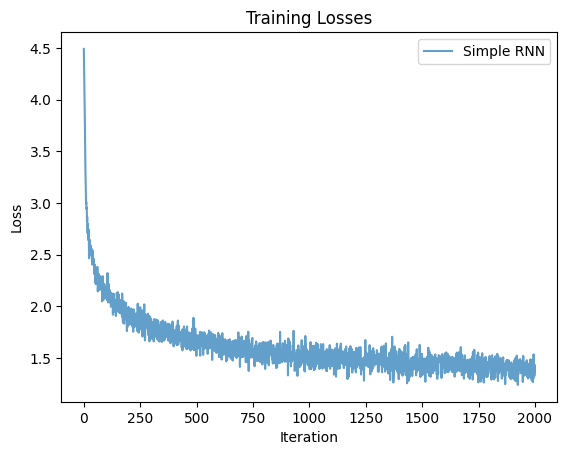


Sample text from Simple RNN: ˜Pmoised and took his are pastyorce,, Swerend tight and Jack she had and purss. One day she kney and
--------------------------------------------------------------------------------


In [6]:
hidden_size = 256
embed_size = 64
simple_rnn = SimpleRNN(len(dataset.vocab), embed_size, hidden_size).to(DEVICE)

simple_rnn_losses = train_language_model(simple_rnn, dataloader, max_iters=2000)
plot_losses({
    "Simple RNN": simple_rnn_losses,
})
# Generate some sample text from the RNN. After maybe 2000 iterations, you should be able to get a loss of 1.4, and see
# something that's recognizably English, but not perfect, with frequent misspellings.
sample_text = simple_rnn.generate_text(dataset)
print(f"\nSample text from Simple RNN: {sample_text}")
print("-" * 80)

# Multi-Layer RNN Architecture

## Basic Idea

Now that we have a single-layer RNN working, let's extend it to multiple layers.

In a multi-layer RNN, each layer processes the output of the previous layer. For layer l, the hidden state update is:

$$
h_t^{(l)} = f_\theta^{(l)}(h_t^{(l-1)}, h_{t-1}^{(l)})
$$

where $h_t^{(l)}$ is the hidden state at time t for layer l.

## Layer-wise Processing

The computation flows as follows:

1. Input embedding (layer 0):
$$h_t^{(0)} = Ex_t$$

2. First RNN layer:
$$h_t^{(1)} = \tanh(W_{ih}^{(1)}h_t^{(0)} + b_{ih}^{(1)} + W_{hh}^{(1)}h_{t-1}^{(1)} + b_{hh}^{(1)})$$

3. Subsequent layers (l > 1):
$$h_t^{(l)} = \tanh(W_{ih}^{(l)}h_t^{(l-1)} + b_{ih}^{(l)} + W_{hh}^{(l)}h_{t-1}^{(l)} + b_{hh}^{(l)})$$

4. Final output prediction:
$$\hat{y}_t = \text{softmax}(W_{out}h_t^{(L)} + b_{out})$$

where L is the total number of layers.

## Information Flow

The network now has two types of connections:
- Temporal connections (within each layer across time steps)
- Deep connections (between layers at each time step)

This allows the network to learn both:
- Temporal features (through recurrent connections)
- Hierarchical features (through layer stacking)


Implement the Multi-Layer RNN below, and then try training it and running it. **[3 points]**

In [7]:
class MultiLayerRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # TODO: Create ModuleLists for W_ih and W_hh
        # HINT: W_ih[0] should map from embed_size to hidden_size
        # subsequent W_ih[l] should map from hidden_size to hidden_size
        self.W_ih = nn.ModuleList([
            nn.Linear(embed_size, hidden_size),
        ] + [
            nn.Linear(hidden_size, hidden_size) # TODO - construct the needed module
            for i in range(num_layers - 1)
        ])

        self.W_hh = nn.ModuleList([
            # YOUR CODE HERE
            nn.Linear(hidden_size, hidden_size) # TODO - construct the needed module
            for i in range(num_layers)
        ])

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.tanh = nn.Tanh()

    def forward(self, x_token, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(x_token.size(0))

        x = self.embedding(x_token)
        new_hidden = []

        for layer in range(self.num_layers):
            # Implement the recurrence for each layer
            layer_input = x if layer == 0 else new_hidden[-1]

            # YOUR CODE HERE: Apply the recurrence formula for this layer.
            # HINT: Use the formula from the markdown above
            # Compute h using self.W_ih[layer], self.W_hh[layer], and self.tanh,
            # (1) incorporating layer_input from layer stacking
            # (2) and the hidden[layer] from the temporal sequencing
            h = self.tanh(
                self.W_ih[layer](layer_input) +
                self.W_hh[layer](hidden[layer])
            )

            new_hidden.append(h)

        logits = self.fc(new_hidden[-1])
        return logits, new_hidden

    def init_hidden(self, batch_size):
        return [torch.zeros(batch_size, self.hidden_size, device=DEVICE)
                for _ in range(self.num_layers)]

    def generate_text(self, dataset, length=100):
        self.eval()
        token = torch.randint(0, len(dataset.vocab), (1,), device=DEVICE)
        generated_tokens = [token.item()]
        hidden = self.init_hidden(1)

        for _ in range(length-1):
            logits, hidden = self(token, hidden)
            # TODO: Convert logits to probabilities and sample the next token
            # HINT: Use torch.multinomial after applying softmax
            probs = torch.softmax(logits, dim=-1)  # YOUR CODE HERE
            token = torch.multinomial(probs, num_samples=1).squeeze(-1)  # YOUR CODE HERE

            generated_tokens.append(token.item())

        generated_text = ''.join([dataset.itos[i] for i in generated_tokens])
        return generated_text

## Multi-Layer RNN Training

The training loop below can be used to test your multi-layer model. You will need to fill in the missing core loop. **[2 points]**

In [8]:
def train_multilayer_rnn(model, dataloader, lr=1e-3, print_every=100, max_iters=None):
    seq_len = dataloader.dataset.seq_length
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    losses = []
    start_time = time.time()

    for step, (x_batch, y_batch) in enumerate(dataloader):
        if max_iters is not None and step >= max_iters:
            break

        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        batch_size = x_batch.size(0)

        # Initialize hidden states for all layers
        h_prev = model.init_hidden(batch_size)
        loss = 0

        # Unroll over seq_len
        for t in range(seq_len):
            ## YOUR CODE HERE
            # This should all look quite similar to your previous training loop
            logits, h_prev = model(x_batch[:, t], h_prev)
            loss_t = criterion(logits, y_batch[:, t])
            loss = loss + loss_t

        loss = loss / seq_len
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (step + 1) % print_every == 0:
            elapsed = time.time() - start_time
            print(f"(Multi-Layer RNN) Step {step+1}, Loss: {loss.item():.4f}, Time: {elapsed:.2f}s")
            start_time = time.time()

    return losses

Experiment with different model sizes and other training configurations, and plot your findings.

(Multi-Layer RNN) Step 100, Loss: 1.9583, Time: 0.72s
(Multi-Layer RNN) Step 200, Loss: 1.7464, Time: 0.71s
(Multi-Layer RNN) Step 300, Loss: 1.7154, Time: 0.71s
(Multi-Layer RNN) Step 400, Loss: 1.6851, Time: 0.71s
(Multi-Layer RNN) Step 500, Loss: 1.6485, Time: 0.70s
(Multi-Layer RNN) Step 600, Loss: 1.5308, Time: 0.71s
(Multi-Layer RNN) Step 700, Loss: 1.4574, Time: 0.71s
(Multi-Layer RNN) Step 800, Loss: 1.5844, Time: 0.71s
(Multi-Layer RNN) Step 900, Loss: 1.5065, Time: 0.71s
(Multi-Layer RNN) Step 1000, Loss: 1.4407, Time: 0.71s
(Multi-Layer RNN) Step 1100, Loss: 1.3735, Time: 0.71s
(Multi-Layer RNN) Step 1200, Loss: 1.3551, Time: 0.71s
(Multi-Layer RNN) Step 1300, Loss: 1.3989, Time: 0.71s
(Multi-Layer RNN) Step 1400, Loss: 1.3982, Time: 0.70s
(Multi-Layer RNN) Step 1500, Loss: 1.2912, Time: 0.71s
(Multi-Layer RNN) Step 1600, Loss: 1.4482, Time: 0.71s
(Multi-Layer RNN) Step 1700, Loss: 1.3921, Time: 0.70s
(Multi-Layer RNN) Step 1800, Loss: 1.3354, Time: 0.70s
(Multi-Layer RNN) S

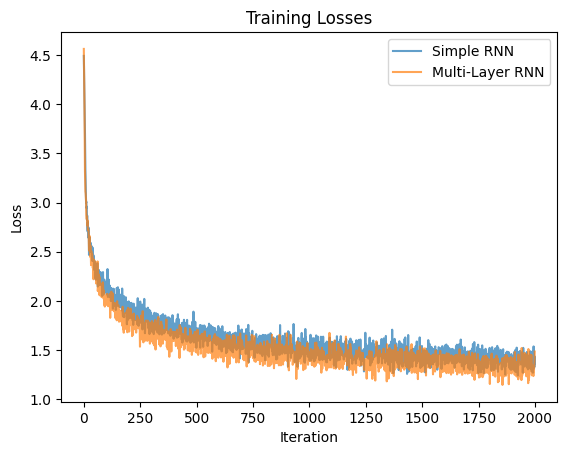


Sample text from Multi-Layer RNN: ¦ to Mia say nods not up. The bear was all coalled to were happy and smile -buitens and parny gronis
--------------------------------------------------------------------------------
(Multi-Layer RNN) Step 100, Loss: 2.1406, Time: 0.72s
(Multi-Layer RNN) Step 200, Loss: 1.7684, Time: 0.70s
(Multi-Layer RNN) Step 300, Loss: 1.5492, Time: 0.71s
(Multi-Layer RNN) Step 400, Loss: 1.5508, Time: 0.71s
(Multi-Layer RNN) Step 500, Loss: 1.5393, Time: 0.70s
(Multi-Layer RNN) Step 600, Loss: 1.5851, Time: 0.71s
(Multi-Layer RNN) Step 700, Loss: 1.5678, Time: 0.70s
(Multi-Layer RNN) Step 800, Loss: 1.4522, Time: 0.70s
(Multi-Layer RNN) Step 900, Loss: 1.4386, Time: 0.71s
(Multi-Layer RNN) Step 1000, Loss: 1.3834, Time: 0.71s
(Multi-Layer RNN) Step 1100, Loss: 1.4228, Time: 0.71s
(Multi-Layer RNN) Step 1200, Loss: 1.3108, Time: 0.71s
(Multi-Layer RNN) Step 1300, Loss: 1.4382, Time: 0.71s
(Multi-Layer RNN) Step 1400, Loss: 1.2095, Time: 0.71s
(Multi-Layer RNN) Step

In [9]:
hidden_size = 256
embed_size = 64
num_layers = 2  # We can experiment with different numbers of layers

multilayer_rnn = MultiLayerRNN(
    vocab_size=len(dataset.vocab),
    embed_size=embed_size,
    hidden_size=hidden_size,
    num_layers=num_layers
).to(DEVICE)

multilayer_rnn_losses = train_multilayer_rnn(multilayer_rnn, dataloader, max_iters=2000)

# Plot both models for comparison
plot_losses({
    "Simple RNN": simple_rnn_losses,
    "Multi-Layer RNN": multilayer_rnn_losses,
})

# Generate sample text from the multilayer RNN
sample_text = multilayer_rnn.generate_text(dataset)
print(f"\nSample text from Multi-Layer RNN: {sample_text}")
print("-" * 80)

# Optional: Compare generations with different numbers of layers
for layers in [2, 3, 4]:
    model = MultiLayerRNN(
        vocab_size=len(dataset.vocab),
        embed_size=embed_size,
        hidden_size=hidden_size,
        num_layers=layers
    ).to(DEVICE)
    losses = train_multilayer_rnn(model, dataloader, max_iters=2000)
    print(f"\nSample text from {layers}-layer RNN:")
    print(model.generate_text(dataset))
    print("-" * 80)

---

# Computational Efficiency of the Classic RNN

Let's analyze the efficiency of the RNN. For an Elman RNN with:
- Hidden dimension D
- Vocabulary size V
- Sequence length T
- Number of layers L

For this exercise, you can assume that the embedding dimension is the same as the hidden dimension D.

</br>

1. How many FLOPs are needed to generate T tokens? (In this, and all the questions in this HW, you can ignore small calculations like biases and assume that there's a single batch. You can also assume that an AxB matrix and a BxC matrix take 2ABC FLOPs to be multiplied together (about half of those are scalar multiplications and half are scalar additions). Don't worry about the final projection to the vocabulary dimension.  Even though we implemented a single layer, in the general case the model could implement L layers per step.) **[1 point]**

> YOUR ANSWER: To process a single token and a single layer we require __2__ matrix multiplications with dimension __D x D__ by __D x 1__, which comes to __4D^2__ FLOPS per token.  Doing it for L layers and T tokens requires a total of __4LTD^2__ FLOPs.

</br>

2. How many FLOPs are needed to train on a sequence of T tokens?  (Not counting training the classifier layer $W_{ff}$.)  **[3 points]**

> YOUR ANSWER: For each layer and for a single token, we need to calculate the gradients with respect to $W_{ih}$ and $W_{hh}$. Each of these is a __D x 1__ by __1 x D__ matrix multiplication which comes to __2D^2__ FLOPS.  We also need to propagate the gradients with respect to the input (to train the embedding), which adds __2D^2__ FLOPS for a single token, and and hidden states (to backpropgate through time) which is __2D^2__ FLOPS per token.   So for each layer and for a single token, we need __8D^2__ FLOPS.  We do this for L layers and T tokens, so the total is __8LTD^2__ FLOPs.

</br>

3. Counting FLOPS can overestimate how expensive neural networks are on a GPU, which can parallelize the operations in a matrix (or matrix-vector) operation very efficiently. Since a modern GPU can process a fairly good-sized matrix multiplication in a small amount of real-world wall-clock time, it can be more informative to count these matrix multiplications.  How many sequential matrix multiplications are needed to generate T tokens?  **[2 points]**

> YOUR ANSWER: For each layer and for a single token, we need __1__ matrix multiplication, So over all L layers and T tokens we need __LT__ sequential matrix multiplications.

</br>

4. How many sequential matrix multiplications are needed to train on T tokens?  **[1 points]**

> YOUR ANSWER: For each layer and for a single token, we need __2__ matrix multiplications, So over all L layers and T tokens we need __2LT__ sequential matrix multiplications.

One limitation of simple RNNs is that they can struggle to capture long-term dependencies due to vanishing gradients during backpropagation through time. Let's test this by increasing the sequence length and observing how the RNN performs.

Step 100, Loss: 2.0136, Time: 2.22s
Step 200, Loss: 1.6973, Time: 2.21s
Step 300, Loss: 1.6348, Time: 2.21s
Step 400, Loss: 1.5536, Time: 2.21s
Step 500, Loss: 1.4893, Time: 2.21s
Step 600, Loss: 1.3916, Time: 2.21s
Step 700, Loss: 1.3463, Time: 2.21s
Step 800, Loss: 1.3619, Time: 2.21s
Step 900, Loss: 1.3455, Time: 2.21s
Step 1000, Loss: 1.2392, Time: 2.21s
Step 1100, Loss: 1.2768, Time: 2.21s
Step 1200, Loss: 1.2064, Time: 2.21s
Step 1300, Loss: 1.2074, Time: 2.21s
Step 1400, Loss: 1.2386, Time: 2.21s
Step 1500, Loss: 1.1865, Time: 2.21s
Step 1600, Loss: 1.1821, Time: 2.21s
Step 1700, Loss: 1.1823, Time: 2.21s
Step 1800, Loss: 1.2509, Time: 2.21s
Step 1900, Loss: 1.1982, Time: 2.21s
Step 2000, Loss: 1.1358, Time: 2.21s
Step 2100, Loss: 1.1970, Time: 2.21s
Step 2200, Loss: 1.2138, Time: 2.21s
Step 2300, Loss: 1.1894, Time: 2.21s
Step 2400, Loss: 1.1695, Time: 2.21s
Step 2500, Loss: 1.1968, Time: 2.22s
Step 2600, Loss: 1.1342, Time: 2.21s
Step 2700, Loss: 1.1340, Time: 2.21s
Step 2800,

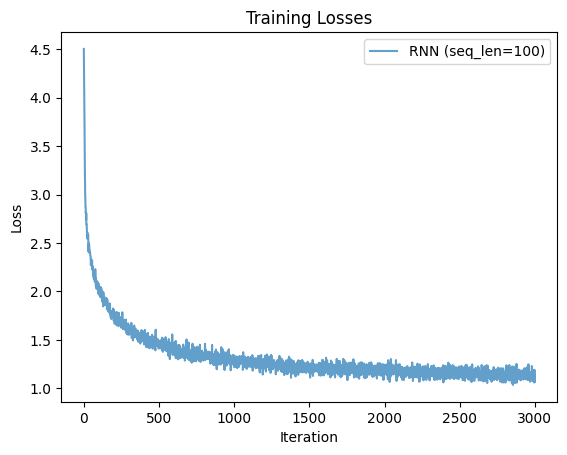

In [10]:
max_iters = 3_000

dataset = CharLMDataset(full_text, seq_length=100)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Train RNN with longer sequences
simple_rnn = SimpleRNN(len(dataset.vocab), embed_size, hidden_size).to(DEVICE)
rnn_losses = train_language_model(simple_rnn, dataloader, max_iters=max_iters)

sample_text = simple_rnn.generate_text(dataset)
print(f"\nSample text from RNN: {sample_text}")
print("-" * 80)

# Plot loss curve
plot_losses({
    "RNN (seq_len=100)": rnn_losses,
})

# Transformer LM

Can we do even better? The Transformer (Vaswani et al., 2017)[https://arxiv.org/abs/1706.03762] seems like a good
candidate. We'll adapt Andrej Karpathy's nanoGPT (https://github.com/karpathy/nanoGPT), itself based on GPT2, to our
setting. nanoGPT uses a pre-LayerNorm architecture, GeLU activations, and simple learned positional encodings.

For another take on implementing a transformer, see the ARENA materials at https://arena-chapter1-transformer-interp.streamlit.app/[1.1]_Transformer_from_Scratch

Here is an implementation guide for the transformer below.

## 1. Main Forward Pass (Transformer class)

The forward pass combines token and positional embeddings, then processes them through transformer blocks:

**Mathematical formulation:**
1. Token embeddings: $E_{tok} = \text{Embedding}(idx) \in \mathbb{R}^{b \times t \times d}$
2. Position embeddings: $E_{pos} = \text{Embedding}(\text{range}(t)) \in \mathbb{R}^{t \times d}$
3. Combined: $x = E_{tok} + E_{pos}$

**Implementation:**
```python
# Get token embeddings
tok_emb = self.transformer.token_embedding(idx)  # shape: (b, t, n_embd)

# Get position embeddings
pos_emb = self.transformer.position_embedding(pos)  # shape: (t, n_embd)

# Combine embeddings
x = tok_emb + pos_emb

# Process through transformer blocks
for block in self.transformer.blocks:
    x = block(x)

# Final layer norm
x = self.transformer.ln_f(x)
```

## 2. Block Forward Pass

Each transformer block applies attention and MLP with residual connections:

**Mathematical formulation:**
1. Attention: $x = x + \text{Attention}(\text{LayerNorm}(x))$
2. MLP: $x = x + \text{MLP}(\text{LayerNorm}(x))$

**Implementation:**
```python
# Attention with residual connection
x = x + self.attn(self.ln_1(x))

# MLP with residual connection
x = x + self.mlp(self.ln_2(x))
```

## 3. Attention Implementation

The self-attention mechanism computes weighted combinations of values based on query-key similarity:

**Mathematical formulation:**
1. Project to Q/K/V: $Q, K, V = WX$ where $W \in \mathbb{R}^{3d \times d}$
2. Attention scores: $A = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + \text{mask}\right)$
3. Output: $y = AV$

**Implementation:**
```python
# Manual implementation of attention (non-flash version)
# Scale dot product of Q and K
att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

# Apply causal mask (sets future positions to -inf before softmax)
att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))

# Apply softmax to get attention weights
att = F.softmax(att, dim=-1)

# Multiply by values
y = att @ v  # shape: (B, nh, T, hs)

# Reshape back: combine all heads
y = y.transpose(1, 2).contiguous().view(B, T, C)
```

## 4. Text Generation

For generating text, we:
1. Start with a sequence containing one random token
2. Repeatedly:
   - Get model predictions
   - Sample next token from the predicted distribution
   - Append to sequence

**Implementation:**
```python
# Model is in eval mode
self.eval()

# Start with a random token
x = torch.randint(0, len(dataset.vocab), (1, 1), device=DEVICE)

for _ in range(max_new_tokens):
    # Get model predictions
    logits, _ = self(x)
    
    # Get probabilities for next token
    logits = logits[:, -1, :]
    probs = F.softmax(logits, dim=-1)
    
    # Sample next token
    x_next = torch.multinomial(probs, num_samples=1)
    
    # Append to sequence
    x = torch.cat((x, x_next), dim=1)

# Convert to text
text = "".join([dataset.itos[i.item()] for i in x[0]])
```

## Implementation Tips

1. **Shape checking**: The most common issues arise from incorrect tensor shapes. Key shapes:
   - Input idx: (batch_size, seq_len)
   - Embeddings: (batch_size, seq_len, n_embd)
   - Attention: (batch_size, n_heads, seq_len, head_size)

2. **Causal masking**: The causal mask ensures tokens can only attend to previous positions:
   ```python
   # Mask shape: (1, 1, seq_len, seq_len)
   mask = torch.tril(torch.ones(block_size, block_size))
   ```

3. **Multi-head attention**: Remember to:
   - Split attention heads: `view(B, T, n_head, head_size)`
   - Transpose for matrix multiplication: `transpose(1, 2)`
   - Combine heads at end: `view(B, T, n_embd)`

[10 points]

In [12]:
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.transformer = nn.ModuleDict(
            dict(
                token_embedding=nn.Embedding(config.vocab_size, config.n_embd),
                position_embedding=nn.Embedding(config.block_size, config.n_embd),
                blocks=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f=nn.LayerNorm(config.n_embd, bias=False),
            )
        )
        self.config = config
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.token_embedding.weight = self.lm_head.weight  # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device)  # shape (t)

        # forward the GPT model itself
        # TODO: implement the transformer forward-pass.  As a guide, see the Main Forward Pass above.
        # YOUR CODE HERE
        tok_emb = self.transformer.token_embedding(idx)
        pos_emb = self.transformer.position_embedding(pos)
        x = tok_emb + pos_emb
        for block in self.transformer.blocks:
            x = block(x)
        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)

        # return tuple to mimic RNNs trained previously
        return logits, None

    @torch.no_grad()
    def generate_text(self, dataset, max_new_tokens=100):
        self.eval()
        # Start with a random token
        x = torch.randint(0, len(dataset.vocab), (1, 1), device=DEVICE)
        # TODO: add the standard autoregressive text generation loop here,
        # as adapted to the transformer.
        # HINT: consult 4. Text Generation above.

        for _ in range(max_new_tokens - 1):
            x_cond = x[:, -self.config.block_size:]
            logits, _ = self(x_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            x_next = torch.multinomial(probs, num_samples=1)
            x = torch.cat((x, x_next), dim=1)

        text = "".join([dataset.itos[i.item()] for i in x[0]])

        return text


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=False)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=False)
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        )

    def forward(self, x):
        # TODO: each block contains both Attention and MLP, in ResNet-style formation
        # Implement that forward pass here.
        # HINT: use the description of 2, Block Forward Pass, above as a guide.
        # YOUR CODE HERE
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.config = config
        # causal mask to ensure that attention is only applied to the left in the input sequence
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size)).view(
                1, 1, config.block_size, config.block_size
            ),
        )

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v = self.c_attn(x).split(self.config.n_embd, dim=2)
        k = k.view(B, T, self.config.n_head, C // self.config.n_head).transpose(1, 2)  # (B, nh, T, hs)
        q = q.view(B, T, self.config.n_head, C // self.config.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.config.n_head, C // self.config.n_head).transpose(1, 2)  # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.config.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=0, is_causal=True)
            y = y.transpose(1, 2).contiguous().view(B, T, C)
        else:
            # manual implementation of attention
            # TODO: implement attention.
            # 1. Use k and q to compute the all-pairs attention weighting
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1))) # YOUR CODE HERE
            # 2. Modify the attention weighting for autoregressive "causal" visibility
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf")) # YOUR CODE HERE
            # 3. Apply softmax
            att = F.softmax(att, dim=-1)  # YOUR CODE HERE
            # 4. Use attention to gather and distribute the v data
            y = att @ v   # YOUR CODE HERE
            # 5. Reshape the data to re-assemble all head outputs for the hidden state
            y = y.transpose(1, 2).contiguous().view(B, T, C)  # YOUR CODE HERE

        # output projection
        y = self.c_proj(y)

        return y


@dataclass
class TransformerConfig:
    vocab_size: int = len(dataset.vocab)
    # Here, we're choosing an embedding size to roughly match the RNN's parameters
    n_embd: int = 128
    block_size: int = 100
    n_layer: int = 1
    n_head: int = 4
    flash: bool = True


# Check that your attention implementation is correct by comparing your CausalSelfAttention to the PyTorch implementation
flash_transformer = Transformer(TransformerConfig(flash=True))
naive_transformer = Transformer(TransformerConfig(flash=False))

# Match weights between the two models
naive_transformer.load_state_dict(flash_transformer.state_dict())

random_input = torch.randint(0, len(dataset.vocab), (2, 8))
flash_output, _ = flash_transformer.forward(random_input)
naive_output, _ = naive_transformer.forward(random_input)

assert torch.allclose(flash_output, naive_output, atol=1e-6), f"differences: {flash_output - naive_output}"

Now let's analyze the efficiency of our Transformer.  With:
- Model dimension D
- Number of heads H
- Head dimension J = D/H
- Sequence length T
- Number of layers L

</br>

1. How many FLOPs are needed to generate T tokens? (You can ignore small calculations like biases and assume that there's a single batch. You can also assume that an AxB matrix and a BxC matrix take 2ABC FLOPs to be multiplied together. Don't worry about the final projection to the vocabulary dimension, or about LayerNorm.)  **[5 points]**

> YOUR ANSWER: For a single layer, the MLP is: __16TD^2__  FLOPs.

> YOUR ANSWER: For a single layer, computing the K, Q, and V togther is: __6TDJ__  FLOPs for each head and __6TD^2__ FLOPS for all heads together.

> YOUR ANSWER: For a single layer, computing the attention matrix is: __2T^2J__  FLOPs for each head and __2T^2D__ FLOPS for all heads together.

> YOUR ANSWER: For a single layer, processing all the values through attention is: __2T^2J__  FLOPs for each head and __2T^2D__ FLOPS for all heads together.

> YOUR ANSWER: After concatentating all head results, the final projection is __2TD^2__ FLOPS

> YOUR ANSWER: Therefore the total flops for a single layer of attention is __8TD^2 + 4T^2D__ FLOPS

> YOUR ANSWER: Adding up all layers the cost to generate T tokens is __L(24TD^2 + 4T^2D)__ FLOPS

</br>

2. How many FLOPs are needed to train on a sequence of T tokens?  **[2 points]**

> YOUR ANSWER: A single forward pass requires __L(24TD^2 + 4T^2D)__ FLOPS and the backward pass requires __L(48TD^2 + 8T^2D)__ FLOPS.

</br>

3. How many sequential matrix multiplications are needed to generate T tokens?  **[3 points]**

> YOUR ANSWER: For a single layer the MLP requires __2__ sequential matrix multiplications.

> YOUR ANSWER: For a single layer, calculating the keys, queries and values can be done in parallel, but the attention matrix must be computed only after generating the keys, queries and values, and processing the balues and doing the final projection must also happen after one another therefore, the attention sub-layer requires __4__ sequential matrix multiplications.

> YOUR ANSWER: There the transformer requires __6__  total sequential matrix multiplications per layer.

> YOUR ANSWER: Considering all layers all together, a foward pass requires __6L__ sequential matrix multiplications.

</br>

4. How many sequential matrix multiplications are needed to train on T tokens, and how does this compare to the RNN?  **[2 points]**

> YOUR ANSWER: Considering all layers all together, a backward pass in a transformer requires __12L__ sequential matrix multiplications.

> YOUR ANSWER: This differs from the cost of training an RNN because __a transformer has no recurrent dependence across timesteps, so all T positions in a layer can be processed in parallel. Its sequential cost scales with depth L rather than with LT, whereas an RNN must be unrolled through time.__


Parameters: 222208
Step 100, Loss: 2.2887, Time: 0.36s
Step 200, Loss: 2.2096, Time: 0.14s
Step 300, Loss: 1.8498, Time: 0.14s
Step 400, Loss: 1.7557, Time: 0.14s
Step 500, Loss: 1.6166, Time: 0.14s
Step 600, Loss: 1.6373, Time: 0.14s
Step 700, Loss: 1.4733, Time: 0.14s
Step 800, Loss: 1.4579, Time: 0.14s
Step 900, Loss: 1.4253, Time: 0.14s
Step 1000, Loss: 1.4102, Time: 0.14s
Step 1100, Loss: 1.4110, Time: 0.14s
Step 1200, Loss: 1.3389, Time: 0.14s
Step 1300, Loss: 1.3955, Time: 0.14s
Step 1400, Loss: 1.2840, Time: 0.14s
Step 1500, Loss: 1.3927, Time: 0.14s
Step 1600, Loss: 1.2846, Time: 0.14s
Step 1700, Loss: 1.3029, Time: 0.14s
Step 1800, Loss: 1.2959, Time: 0.14s
Step 1900, Loss: 1.3281, Time: 0.14s
Step 2000, Loss: 1.2648, Time: 0.14s
Step 2100, Loss: 1.3242, Time: 0.14s
Step 2200, Loss: 1.1990, Time: 0.14s
Step 2300, Loss: 1.2252, Time: 0.14s
Step 2400, Loss: 1.1582, Time: 0.14s
Step 2500, Loss: 1.2183, Time: 0.14s
Step 2600, Loss: 1.3028, Time: 0.14s
Step 2700, Loss: 1.2050, Tim

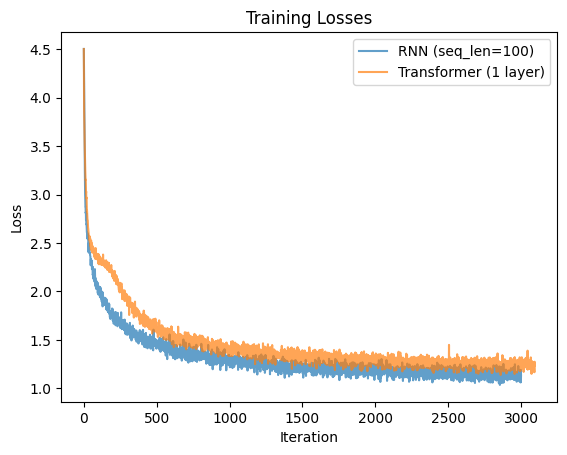

In [13]:
# Now let's see how the Transformer performs on our dataset.

seq_length = 100
batch_size = 32
lr = 1e-3

dataset = CharLMDataset(full_text, seq_length=seq_length)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

transformer_model = Transformer(TransformerConfig()).to(DEVICE)

print(f"Parameters: {sum(p.numel() for p in transformer_model.parameters())}")

transformer_losses = train_language_model(transformer_model, dataloader, lr=lr, max_iters=15_000, is_rnn=False)

# Compare training iterations
print(f"Training iterations - Transformer: {len(transformer_losses)}, RNN: {len(rnn_losses)}")

# Generate sample text from Transformer
sample_text = transformer_model.generate_text(dataset)
print(f"\nSample text from Transformer: {sample_text}")
print("-" * 80)

# Plot the loss curves comparing RNN and Transformer
plot_losses({
    "RNN (seq_len=100)": rnn_losses,
    "Transformer (1 layer)": transformer_losses,
})

(Multi-Layer RNN) Step 100, Loss: 3.0986, Time: 10.52s
(Multi-Layer RNN) Step 200, Loss: 3.0640, Time: 10.32s
(Multi-Layer RNN) Step 300, Loss: 3.1034, Time: 10.32s
(Multi-Layer RNN) Step 400, Loss: 3.0685, Time: 10.29s
(Multi-Layer RNN) Step 500, Loss: 3.0749, Time: 10.31s
(Multi-Layer RNN) Step 600, Loss: 3.0770, Time: 10.30s
(Multi-Layer RNN) Step 700, Loss: 3.1110, Time: 10.32s
(Multi-Layer RNN) Step 800, Loss: 3.0106, Time: 10.31s
(Multi-Layer RNN) Step 900, Loss: 2.6038, Time: 10.31s
(Multi-Layer RNN) Step 1000, Loss: 2.3671, Time: 10.32s
(Multi-Layer RNN) Step 1100, Loss: 2.0966, Time: 10.31s
(Multi-Layer RNN) Step 1200, Loss: 1.9155, Time: 10.31s
(Multi-Layer RNN) Step 1300, Loss: 1.8237, Time: 10.31s
(Multi-Layer RNN) Step 1400, Loss: 1.7760, Time: 10.31s
(Multi-Layer RNN) Step 1500, Loss: 1.6429, Time: 10.30s
(Multi-Layer RNN) Step 1600, Loss: 1.5997, Time: 10.29s
(Multi-Layer RNN) Step 1700, Loss: 1.5448, Time: 10.30s
(Multi-Layer RNN) Step 1800, Loss: 1.4727, Time: 10.31s
(

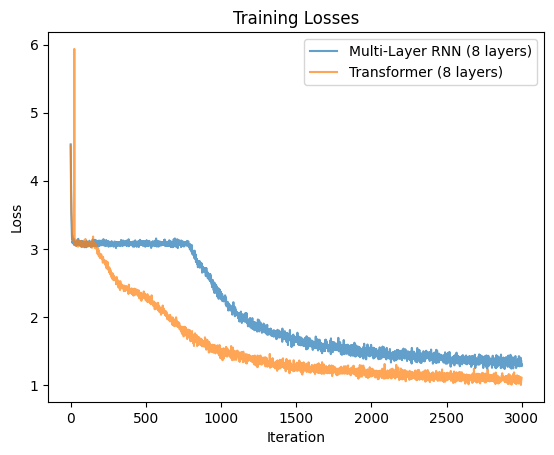

In [14]:
# The single-layer Transformer showed limited improvement over the RNN. In Deep Learning, adding
# more layers often helps - but only if the architecture can handle the depth. Here, we compare
# an 8-layer RNN and an 8-layer Transformer, roughly parameter-matched, to see how each
# architecture scales with depth.

max_iters = 3_000

# Create a multi-layer RNN to match the Transformer architecture
rnn_model = MultiLayerRNN(
    vocab_size=len(dataset.vocab),
    embed_size=32,
    hidden_size=192,
    num_layers=8  # Match Transformer layer count
).to(DEVICE)

# Train the multi-layer RNN
rnn_losses = train_multilayer_rnn(rnn_model, dataloader, lr=lr, max_iters=max_iters)
print(f"RNN parameters: {sum(p.numel() for p in rnn_model.parameters()):.1e}")

sample_text = rnn_model.generate_text(dataset)
print(f"\nSample text from Multi-Layer RNN: {sample_text}")
print("-" * 80)

# Now train an 8-layer Transformer for comparison
cfg = TransformerConfig(
    vocab_size=len(dataset.vocab),
    n_embd=128,
    block_size=seq_length,
    n_layer=8,
    n_head=4,
    flash=True,
)

transformer_model = Transformer(cfg).to(DEVICE)
print(f"Transformer parameters: {sum(p.numel() for p in transformer_model.parameters()):.1e}")

transformer_losses = train_language_model(transformer_model, dataloader, lr=lr, max_iters=max_iters, is_rnn=False)

sample_text = transformer_model.generate_text(dataset)
print(f"\nSample text from Transformer: {sample_text}")
print("-" * 80)

# Compare the two architectures
plot_losses({
    "Multi-Layer RNN (8 layers)": rnn_losses,
    "Transformer (8 layers)": transformer_losses,
})

# There are two key observations here. First, the Multi-Layer RNN struggles significantly with
# vanishing gradients as depth increases, making training unstable. The Transformer's residual
# connections, layer normalization, and GELU activations help it successfully propagate gradients
# through all 8 layers. Second, the Transformer trains much faster - it can process entire sequences
# in parallel, while the RNN must process tokens sequentially. Flash attention (Dao et al., 2022)
# [https://arxiv.org/abs/2205.14135] further accelerates the Transformer, but even the basic
# implementation benefits from parallelization.

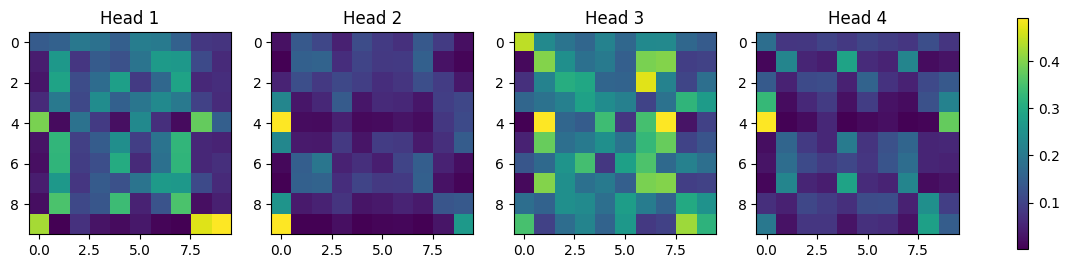

In [15]:
# Transformers are ubiquitous. It would be nice to understand them better. One way people have tried to this is to look
# at their attention patterns. Let's try to do this for our models.


# Add a helper function to visualize attention patterns
def plot_attention_patterns(model, text, dataset):
    """Visualize the attention patterns for a given input text"""
    # Convert text to tokens
    tokens = [dataset.stoi[c] for c in text]
    x = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    # Get attention weights
    with torch.no_grad():
        B, T = x.size()
        block = model.transformer.blocks[0]
        q, k, v = block.attn.c_attn(block.ln_1(model.transformer.token_embedding(x))).split(model.config.n_embd, dim=2)
        k = k.view(B, T, model.config.n_head, -1).transpose(1, 2)
        q = q.view(B, T, model.config.n_head, -1).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)

    # Plot heatmap for each attention head
    fig, axes = plt.subplots(1, model.config.n_head, figsize=(15, 3))
    for h in range(model.config.n_head):
        im = axes[h].imshow(att[0, h].cpu())
        axes[h].set_title(f"Head {h + 1}")
    plt.colorbar(im, ax=axes)
    plt.show()

plot_attention_patterns(transformer_model, "Lily said,", dataset)

# Experiment with some more input examples. Do you notice anything about how the patterns change? Do particular heads
# behave differently from each other? How?

---

# Real-World Tokenization: Subword Models

So far we've used character-level tokenization (vocab size ~100). Production models use **subword tokenization** (vocab size 8k-32k) which:
- Captures common word patterns efficiently (e.g., "ing", "tion" as single tokens)
- Handles rare words better through subword decomposition  
- Significantly improves model performance

We'll use **SentencePiece** (used in GPT, BERT, T5) to see the difference.

</br>
</br>

## **[11 Points] Exercise:** Train a subword tokenizer and compare it to character-level models.

In [16]:
# install sentencepiece if not already installed
!pip install sentencepiece

[2 points]

In [34]:
import sentencepiece as spm
import os

# TODO: Choose vocabulary size (common range: 8000-16000)
# Larger vocab = more tokens learned, but larger embedding tables
VOCAB_SIZE = 8000  # YOUR CODE HERE

# TODO: Choose model type: "bpe" (Byte Pair Encoding) or "unigram"
# BPE merges frequent pairs; unigram uses probabilistic subwords
MODEL_TYPE = "bpe"  # YOUR CODE HERE

# Create tokenizer directory
TOK_DIR = "/tmp/spm_tokenizer"
os.makedirs(TOK_DIR, exist_ok=True)

# Save training data
train_txt = os.path.join(TOK_DIR, "train.txt")
with open(train_txt, "w", encoding="utf-8") as f:
    f.write(full_text)

# TODO: Train the tokenizer
# Fill in the vocab_size and model_type parameters below
# Hint: use the variables you defined above
spm.SentencePieceTrainer.Train(
    input=train_txt,
    model_prefix=os.path.join(TOK_DIR, "spm"),
    vocab_size=VOCAB_SIZE,  # YOUR CODE HERE
    model_type=MODEL_TYPE,  # YOUR CODE HERE
    character_coverage=1.0,  # Cover all characters in training data
    bos_id=1, eos_id=2, unk_id=0, pad_id=3  # Special token IDs
)

# Load trained tokenizer
sp = spm.SentencePieceProcessor(model_file=os.path.join(TOK_DIR, "spm.model"))
print(f"Tokenizer vocab size: {sp.vocab_size()}")

# Test the tokenizer
test_text = "Once upon a time there was a little girl"
tokens = sp.encode(test_text)
decoded = sp.decode(tokens)
print(f"\nOriginal: {test_text}")
print(f"Tokens: {tokens}")
print(f"Token pieces: {[sp.id_to_piece(id) for id in tokens]}")
print(f"Decoded: {decoded}")

Tokenizer vocab size: 8000

Original: Once upon a time there was a little girl
Tokens: [172, 183, 6, 138, 142, 28, 6, 135, 186]
Token pieces: ['▁Once', '▁upon', '▁a', '▁time', '▁there', '▁was', '▁a', '▁little', '▁girl']
Decoded: Once upon a time there was a little girl


[3 points]

In [35]:
class SubwordLMDataset(Dataset):
    def __init__(self, text, sp, seq_length=20):
        """
        Create a dataset using subword tokenization.

        Args:
            text: Raw text string
            sp: Trained SentencePiece processor
            seq_length: Length of each sequence
        """
        self.seq_length = seq_length
        self.sp = sp

        # TODO: Encode the entire text using the tokenizer
        # Add BOS (beginning of sentence) token at the start
        # Hint: sp.encode(text) returns a list of token IDs
        #       sp.bos_id() returns the BOS token ID
        self.encoded_text = [sp.bos_id()] + sp.encode(text)  # YOUR CODE HERE

        # Trim to make valid chunks (same as CharLMDataset)
        self.encoded_text = self.encoded_text[: len(self.encoded_text) - (len(self.encoded_text) % (seq_length + 1))]

    def __len__(self):
        # TODO: Return the number of complete sequences
        # IMPORTANT: Each sequence needs (seq_length + 1) tokens to create
        # input (seq_length tokens) and target (seq_length tokens, shifted by 1)
        # Hint: Divide by (seq_length + 1)
        return len(self.encoded_text) // (self.seq_length + 1)  # YOUR CODE HERE

    def __getitem__(self, idx):
        # TODO: Extract a sequence chunk for training
        # Get tokens from position [idx * (seq_length+1)] to [(idx+1) * (seq_length+1)]
        # This ensures non-overlapping sequences (each chunk is seq_length+1 tokens long)
        # Hint: chunk = self.encoded_text[start:end]
        chunk = self.encoded_text[idx * (self.seq_length + 1) : (idx + 1) * (self.seq_length + 1)]  # YOUR CODE HERE

        # Input: all tokens except the last
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        # Target: all tokens except the first (shifted by 1)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

# Create dataset and dataloader
subword_dataset = SubwordLMDataset(full_text, sp, seq_length=100)
subword_dataloader = DataLoader(subword_dataset, batch_size=32, shuffle=True, drop_last=True)

print(f"\nDataset created successfully!")
print(f"Subword vocab size: {sp.vocab_size()}")
print(f"Character vocab size (from earlier): {len(dataset.vocab)}")
print(f"Number of sequences: {len(subword_dataset)}")


Dataset created successfully!
Subword vocab size: 8000
Character vocab size (from earlier): 92
Number of sequences: 23369


[2 point]

Training RNN with subword tokenization...
Step 200, Loss: 4.6946, Time: 4.82s
Step 400, Loss: 4.1036, Time: 4.80s
Step 600, Loss: 3.8135, Time: 4.81s

Generating sample text...

Subword RNN sample:
them airplane would take." They wanted to help his room. But then, they went wealthy angry, and saw a very sandwich. One day, Bob decided to help the ship sent come right for it. Suddenly one eyes did stood, "Don't worry, the furry forks. Her mom value them some taking. "Can I have you away,â€TMt!" Ben says. "Why he did you." she was Tom and Lily and she. She went the washing to watch the fire and
--------------------------------------------------------------------------------


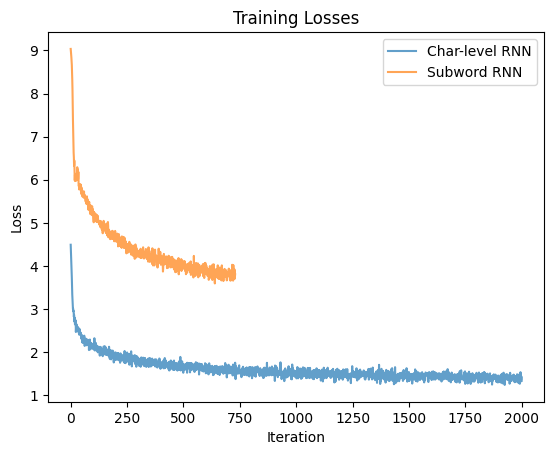

In [36]:
# Train SimpleRNN with subword tokenization
print("Training RNN with subword tokenization...")

subword_rnn = SimpleRNN(
    vocab_size=sp.vocab_size(),  # TODO: Use the tokenizer's vocabulary size (sp.vocab_size())
    embed_size=64,
    hidden_size=256
).to(DEVICE)

subword_rnn_losses = train_language_model(
    subword_rnn,
    subword_dataloader,
    max_iters=2000,
    print_every=200
)

# Generate sample text
print("\nGenerating sample text...")
# Note: generate_text returns token IDs, we need to decode them
with torch.no_grad():
    subword_rnn.eval()
    token = torch.randint(0, sp.vocab_size(), (1,), device=DEVICE)
    generated_tokens = [token.item()]
    hidden = subword_rnn.init_hidden(1)

    for _ in range(100):
        logits, hidden = subword_rnn(token, hidden)
        probs = torch.softmax(logits, dim=-1)
        token = torch.multinomial(probs, num_samples=1).squeeze(-1)
        generated_tokens.append(token.item())

sample_text = sp.decode(generated_tokens)
print(f"\nSubword RNN sample:\n{sample_text}")
print("-" * 80)

# Compare with character-level model
plot_losses({
    "Char-level RNN": simple_rnn_losses,
    "Subword RNN": subword_rnn_losses
})

## Analysis: Character vs Subword Tokenization

Compare your results and answer the following:

1. Compare final loss values. Is subword tokenization better? Why? **[1 point]**

> No, the character-level RNN performed better. Its final loss is much lower (about $1.4$ to $1.5$) than the subword RNN’s final loss (about $3.7$ to $3.9$), so empirically the character model won here. One important caveat is that these losses are kind of apples-to-oranges, because cross-entropy is computed over C classes and the subword model predicts over a much larger vocabulary than the character model.

</br>

2. Compare the generated text from both models. Which produces more coherent text? Give specific examples.  **[1 point]**

> Based on our experimental results, the character-level model appears to be more coherent overall. The subword model does produce some locally sensible phrases, such as “Bob decided to help the ship sent come right for it”, which shows that it has learned some meaningful chunks. However, it still breaks down in obvious ways, for example “Can I have you away,â€TMt!”, which are clear signs of malformed word generation and semantic drift. So in this particular experiment, the subword output is only partially coherent, while the much lower character-level loss suggests the character model is behaving more consistently. Subword methods are generally supposed to help by keeping common words intact and splitting rare words into reusable pieces, but that advantage did not seem to materialize here.

</br>

3. The subword model has a vocabulary ~100x larger than character-level. Despite this, why does it converge faster or achieve better performance?  **[1 point]**

> In general, subword tokenization can help because it lets the model represent frequent words or morphemes as single tokens, while still breaking rare words into known subwords. That usually means shorter effective sequences and better handling of the open-vocabulary problem. SentencePiece is explicitly designed for this fixed-size subword setting, and modern tokenizers use subwords for exactly that reason. However, that benefit did not show up clearly in our training run. A likely reason is that this is a relatively small specialist RNN trained for a limited number of updates, while the subword model must predict over a much larger output class space, which makes optimizating for this task harder.

</br>

4. When would you prefer character-level tokenization over subword tokenization? Consider factors like languages, domain-specific text, and model size.  **[1 point]**

> I would prefer character-level tokenization when exact character information matters, such as spelling, string manipulation, OCR-like noise, or typo-heavy text. I would also prefer it when the text contains lots of unusual identifiers, symbols, or highly specialized terminology that a generic subword vocabulary may segment poorly. It can also be attractive when you want a very small, simple vocabulary instead of a large learned tokenizer.

</br>

### **[6 points] Extra-credit (optional):**

Try training a Transformer with subword tokenization and compare all four combinations: (Char/Subword) × (RNN/Transformer). Which performs best?

Training character-level RNN...
Step 200, Loss: 1.7503, Time: 4.84s
Step 400, Loss: 1.5330, Time: 4.84s
Step 600, Loss: 1.4510, Time: 4.82s
Step 800, Loss: 1.3535, Time: 4.82s
Step 1000, Loss: 1.2349, Time: 4.82s
Step 1200, Loss: 1.2790, Time: 4.82s
Step 1400, Loss: 1.1913, Time: 4.82s
Step 1600, Loss: 1.1977, Time: 4.82s
Step 1800, Loss: 1.1940, Time: 4.82s
Step 2000, Loss: 1.1323, Time: 4.83s

Training character-level Transformer...
Step 200, Loss: 2.1715, Time: 0.28s
Step 400, Loss: 1.6763, Time: 0.27s
Step 600, Loss: 1.5350, Time: 0.27s
Step 800, Loss: 1.4796, Time: 0.27s
Step 1000, Loss: 1.4147, Time: 0.27s
Step 1200, Loss: 1.4008, Time: 0.27s
Step 1400, Loss: 1.3334, Time: 0.27s
Step 1600, Loss: 1.3560, Time: 0.27s
Step 1800, Loss: 1.2979, Time: 0.27s
Step 2000, Loss: 1.3382, Time: 0.27s

Training subword-level RNN...
Step 200, Loss: 4.6685, Time: 4.75s
Step 400, Loss: 4.0438, Time: 4.74s
Step 600, Loss: 3.9759, Time: 4.75s
Step 800, Loss: 3.6226, Time: 4.74s
Step 1000, Loss: 3.5

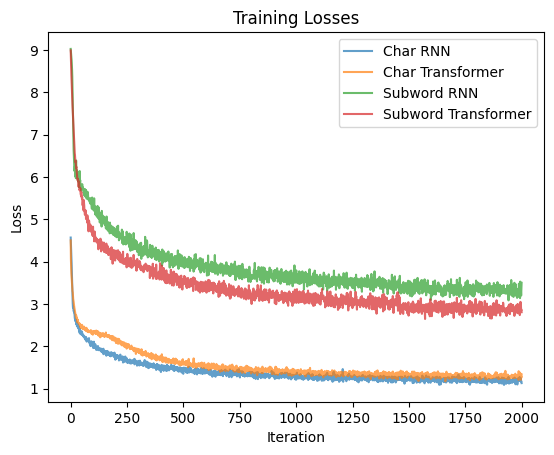


Character-level RNN sample:
From tower. Ale uppy to do it.
Once usice to couice the tried to onje and shiny said, "Maybe made his beenly started to wave in the way, aporie walked her hands."

Lily see a strong that it was too ha
--------------------------------------------------------------------------------
Character-level Transformer sample:
5't like not he decided alown to thday to wants too seafully had.
Once there was a little boy wholer grandt boy, she mom to his got and rockeed the upon as the to pen in she was insteart faside that.

--------------------------------------------------------------------------------
Subword-level RNN sample:
she didn't a song. There were so hungry named Tim and her mom were so surprised when they had a senseive. They don't want to know the turkey is the colors. It read unknown and mother. They like to swim together in the dolls of Mia. Lily liked one of the tower with a big, like she wanted to play with her mom. One day, a friend came while they w

In [40]:
required_names = [
    "full_text",
    "sp",
    "CharLMDataset",
    "SubwordLMDataset",
    "SimpleRNN",
    "Transformer",
    "TransformerConfig",
    "plot_losses",
    "DEVICE",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier notebook cells first. Missing required objects: "
        + ", ".join(missing)
    )

SEQ_LENGTH = 100
BATCH_SIZE = 32
LR = 1e-3
MAX_ITERS = 2000

char_dataset_ec = CharLMDataset(full_text, seq_length=SEQ_LENGTH)
char_dataloader_ec = DataLoader(
    char_dataset_ec,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

subword_dataset_ec = SubwordLMDataset(full_text, sp, seq_length=SEQ_LENGTH)
subword_dataloader_ec = DataLoader(
    subword_dataset_ec,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

def infinite_dataloader(dataloader):
    while True:
        for batch in dataloader:
            yield batch

def train_language_model_fixed_steps(
    model,
    dataloader,
    lr=1e-3,
    print_every=200,
    max_iters=1000,
    is_rnn=True,
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    model.train()

    iterator = infinite_dataloader(dataloader)
    start_time = time.time()

    for step in range(max_iters):
        x_batch, y_batch = next(iterator)
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if is_rnn:
            h = model.init_hidden(x_batch.size(0))
            loss = 0.0
            for t in range(x_batch.size(1)):
                logits, h = model(x_batch[:, t], h)
                loss = loss + criterion(logits, y_batch[:, t])
            loss = loss / x_batch.size(1)
        else:
            logits, _ = model(x_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (step + 1) % print_every == 0:
            elapsed = time.time() - start_time
            print(f"Step {step + 1}, Loss: {loss.item():.4f}, Time: {elapsed:.2f}s")
            start_time = time.time()

    return losses

@torch.no_grad()
def generate_subword_sample(model, sp, max_new_tokens=100, is_rnn=True):
    model.eval()

    generated_ids = [sp.bos_id()]

    if is_rnn:
        hidden = model.init_hidden(1)
        token = torch.tensor([sp.bos_id()], dtype=torch.long, device=DEVICE)

        for _ in range(max_new_tokens):
            logits, hidden = model(token, hidden)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, num_samples=1).squeeze(-1)
            next_id = int(token.item())
            if next_id == sp.eos_id():
                break
            generated_ids.append(next_id)
    else:
        x = torch.tensor([[sp.bos_id()]], dtype=torch.long, device=DEVICE)

        for _ in range(max_new_tokens):
            x_cond = x[:, -model.config.block_size:]
            logits, _ = model(x_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            next_id = int(next_token.item())
            if next_id == sp.eos_id():
                break
            generated_ids.append(next_id)
            x = torch.cat([x, next_token], dim=1)

    ids_to_decode = [
        idx for idx in generated_ids
        if idx not in {sp.bos_id(), sp.eos_id(), sp.pad_id()}
    ]
    return sp.decode(ids_to_decode)

# Train character-level RNN
print("Training character-level RNN...")
char_rnn_ec = SimpleRNN(
    vocab_size=len(char_dataset_ec.vocab),
    embed_size=64,
    hidden_size=256,
).to(DEVICE)
char_rnn_losses_ec = train_language_model_fixed_steps(
    char_rnn_ec,
    char_dataloader_ec,
    lr=LR,
    max_iters=MAX_ITERS,
    print_every=200,
    is_rnn=True,
)

# Train character-level Transformer
print("\nTraining character-level Transformer...")
char_transformer_cfg_ec = TransformerConfig(
    vocab_size=len(char_dataset_ec.vocab),
    n_embd=128,
    block_size=SEQ_LENGTH,
    n_layer=1,
    n_head=4,
    flash=True,
)
char_transformer_ec = Transformer(char_transformer_cfg_ec).to(DEVICE)
char_transformer_losses_ec = train_language_model_fixed_steps(
    char_transformer_ec,
    char_dataloader_ec,
    lr=LR,
    max_iters=MAX_ITERS,
    print_every=200,
    is_rnn=False,
)

# Train subword-level RNN
print("\nTraining subword-level RNN...")
subword_rnn_ec = SimpleRNN(
    vocab_size=sp.vocab_size(),
    embed_size=64,
    hidden_size=256,
).to(DEVICE)
subword_rnn_losses_ec = train_language_model_fixed_steps(
    subword_rnn_ec,
    subword_dataloader_ec,
    lr=LR,
    max_iters=MAX_ITERS,
    print_every=200,
    is_rnn=True,
)

# Train subword-level Transformer
print("\nTraining subword-level Transformer...")
subword_transformer_cfg_ec = TransformerConfig(
    vocab_size=sp.vocab_size(),
    n_embd=128,
    block_size=SEQ_LENGTH,
    n_layer=1,
    n_head=4,
    flash=True,
)
subword_transformer_ec = Transformer(subword_transformer_cfg_ec).to(DEVICE)
subword_transformer_losses_ec = train_language_model_fixed_steps(
    subword_transformer_ec,
    subword_dataloader_ec,
    lr=LR,
    max_iters=MAX_ITERS,
    print_every=200,
    is_rnn=False,
)

# Plot all four loss curves
plot_losses({
    "Char RNN": char_rnn_losses_ec,
    "Char Transformer": char_transformer_losses_ec,
    "Subword RNN": subword_rnn_losses_ec,
    "Subword Transformer": subword_transformer_losses_ec,
})

# Generate samples
print("\nCharacter-level RNN sample:")
print(char_rnn_ec.generate_text(char_dataset_ec, length=200))
print("-" * 80)

print("Character-level Transformer sample:")
print(char_transformer_ec.generate_text(char_dataset_ec, max_new_tokens=200))
print("-" * 80)

print("Subword-level RNN sample:")
print(generate_subword_sample(subword_rnn_ec, sp, max_new_tokens=100, is_rnn=True))
print("-" * 80)

print("Subword-level Transformer sample:")
print(generate_subword_sample(subword_transformer_ec, sp, max_new_tokens=100, is_rnn=False))
print("-" * 80)

final_losses_ec = {
    "Char RNN": char_rnn_losses_ec[-1],
    "Char Transformer": char_transformer_losses_ec[-1],
    "Subword RNN": subword_rnn_losses_ec[-1],
    "Subword Transformer": subword_transformer_losses_ec[-1],
}

print("\nFinal losses:")
for name, loss_value in sorted(final_losses_ec.items(), key=lambda item: item[1]):
    print(f"{name}: {loss_value:.4f}")

best_model_name = min(final_losses_ec, key=final_losses_ec.get)
print(f"\nThe best model was {best_model_name}")